In [643]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Razumevanje Podataka

### Učitavanje podataka

In [644]:
import pandas as pd
df = pd.read_csv("hf://datasets/sairamn/gcp-cloud-billing-cost/data.csv")

### Opisivanje podataka

Dataset koji smo izabrali sadrži sledeće atribute <br>
Resource ID - id resursa <br>
Service Name - Naziv GCP servisa <br>
Usage Quantity - Količina utrošenog resursa <br>
Usage Unit - Jedinica utrošenog resursa <br>
Region / Zone - Regija u kojoj se nalazi resurs <br>
CPU Utilization - Iskorišćenost procesora izražena u procentima <br>
Memory Utilization - Utoršenost memorije <br>
Network Inbound Data (Bytes) - Količina bajtova koju servis šalje preko mreže<br>
Network Outbound Data (Bytes) - Količina bajtova koju servis prima preko mreže<br>
Usage Start Date - Početak korišćenja <br>
Usage End Date - Kraj korišćenja <br>
Cost per Quanitity - Jedinična cena resursa <br>
Unrounded Cost - Nezaukružena cena <br>
Rounded Cost - Zaokružena cena <br>


Dataset ne poseduje NA vrednosti tako da nije potrebno vršiti čišćenje opservacija

In [645]:
df.shape

(124275, 15)

In [646]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Resource ID                    124275 non-null  str    
 1   Service Name                   124275 non-null  str    
 2   Usage Quantity                 124275 non-null  float64
 3   Usage Unit                     124275 non-null  str    
 4   Region / Zone                  124275 non-null  str    
 5   CPU Utilization (%)            124275 non-null  float64
 6   Memory Utilization (%)         124275 non-null  float64
 7   Network Inbound Data (Bytes)   124275 non-null  float64
 8   Network Outbound Data (Bytes)  124275 non-null  float64
 9   Usage Start Date               124275 non-null  str    
 10  Usage End Date                 124275 non-null  str    
 11  Cost per Quantity ($)          124275 non-null  float64
 12  Unrounded Cost ($)             124275 non

In [647]:
df.isna().sum().sum()

np.int64(0)

Cilj ovog modela je da uspesno predvidi troskove koriscenja cloud resursa za N nedelja. Konkretno nasa ideja je da uradimo Rolling sumu sa fiksnim klizecim prozorom, koja ce nam omoguciti da sabiramo troskove agregiranih redova po resurs ID-ju i po nedelji za fiksni interval od N nedelja.

Pre nego sto uradimo samu agregaciju, potrebno je da proverimo kvalitet podataka i da li je korektno raditi grupaciju po ova dva atributa

### Provera kvaliteta podataka i prirode promenljivi

Kako bismo uradili agregaciju potrebno je da proverimo da li je pravilno vrsiti grupaciju prema Resource ID-ju i Danu. Postoje i druge kategoricke promenljive po kojima je moguce vrsiti grupaciju, kao sto su Service Name, Usage Unit i Region / Zone

Smatramo da je nasa pocetna grupacija ispravna, jer na GCP-u jedan resurs id se moze odnositi samo na jednu vrstu cloud servisa. Takodje u generalno jedan cloud resurs sa jedinstvenim id-jem moze se nalaziti u jednom Regionu, isto vazi i za zonu dostupnosti, generalno je moguce imati jednu instancu samo u jednoj zoni, tako da cemo se u ovoj analizi predrzavati tog pravila. Usage Unit je kategoricka promenljiva koja je direktno povezana sa vrstom servisa i izbacicemo je iz razmatranja u daljem delu analize

In [648]:
print(df.groupby("Service Name")["Usage Unit"].unique())

Service Name
App Engine              [Hours]
Artifact Registry          [GB]
BigQuery             [Requests]
Cloud Armor          [Requests]
Cloud Build          [Requests]
Cloud CDN            [Requests]
Cloud Dataflow          [Hours]
Cloud Dataproc          [Hours]
Cloud Filestore            [GB]
Cloud Functions      [Requests]
Cloud Logging              [GB]
Cloud Memorystore          [GB]
Cloud Monitoring           [GB]
Cloud Pub/Sub        [Requests]
Cloud Run            [Requests]
Cloud SQL               [Hours]
Cloud Scheduler      [Requests]
Cloud Spanner           [Hours]
Cloud Storage              [GB]
Cloud Tasks          [Requests]
Compute Engine          [Hours]
Dialogflow           [Requests]
Secret Manager       [Requests]
Name: Usage Unit, dtype: object


Od numerickih promenljivi cemo na prvi pogled izbaciti kolone Rounded Cost i Total Cost koje zajedno sa promenljivom Unrounded Cost, predstavljaju izlaznu varijablu koju mi predvidjamo. Ove promenljive su izvedene jedna iz druge pa je kolinearnost veoma visoka. Ostavicemo samo kolonu Unrounded Cost.

In [649]:
df.drop(columns=['Usage Unit','Total Cost (INR)','Rounded Cost ($)'],inplace=True)

Nakon toga izdvojicemo iz promenljivih tipa datum sledeca vazna obelezja: <br>
Promenljivu week koja omogucava smisleno poredjenje datuma <br>
Promenljivu duration_of_hours koja oznacava trajanje koriscenja resursa <br>

In [650]:
df['Usage Start Date'] = pd.to_datetime(df['Usage Start Date'],errors='raise')
df['Usage End Date'] = pd.to_datetime(df['Usage End Date'],errors='raise')

df["week"] = df["Usage Start Date"].dt.to_period("W").dt.start_time
df['duration_hours'] = (df['Usage End Date'] - df['Usage Start Date']).dt.total_seconds() / 3600
df.drop(columns=['Usage Start Date', 'Usage End Date'],inplace=True)

Nakon toga prikazujemo jos jednom tipove promenljivih

In [651]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Resource ID                    124275 non-null  str           
 1   Service Name                   124275 non-null  str           
 2   Usage Quantity                 124275 non-null  float64       
 3   Region / Zone                  124275 non-null  str           
 4   CPU Utilization (%)            124275 non-null  float64       
 5   Memory Utilization (%)         124275 non-null  float64       
 6   Network Inbound Data (Bytes)   124275 non-null  float64       
 7   Network Outbound Data (Bytes)  124275 non-null  float64       
 8   Cost per Quantity ($)          124275 non-null  float64       
 9   Unrounded Cost ($)             124275 non-null  float64       
 10  week                           124275 non-null  datetime64[us]
 11  duration_ho

Takodje cemo izbaciti iz dataset-a, dve numericke promenljive koje logicki jako dobro predvidjaju izlazni trosak resursa a to su cost per quantity i Usage Quantity jer ce model davati jako veliki znacaj ovim atributima, sto nije nas fokus. Nas fokus je da se predvidja buduca potrosnja na osnovu istorijske tako da ce se ovde koristiti samo Usage Quantity kao istorijski podatak o iskoriscenosti

In [652]:
df.drop(columns='Cost per Quantity ($)',inplace=True)

Pre same agregacije izvrsicemo proveru negativnih vrednosti numerickih promenljiva, koje mogu nastati greskom upisa ili iz drugih tehnickih razloga kao sto su pretpostavljamo GCP krediti. U svakom slucaju izbacicemo one redove koje imaju negativne vrednosti

In [653]:
num_cols = ['Usage Quantity','CPU Utilization (%)','Memory Utilization (%)','Network Inbound Data (Bytes)','Network Outbound Data (Bytes)', 'Unrounded Cost ($)','duration_hours']

In [654]:
positive_instances = (df[num_cols] >= 0).all(axis=1)
df = df[positive_instances].reset_index(drop=True)

Nakon izbacivanja negativnih opservacija, radimo agregaciju po resursnom ID-ju (instanca cloud servisa) i nedelje. Konkretan razlog zasto ne radimo agregaciju po danima je zato sto dataset ne poseduje dovoljno unosa, da bi moglo kvalitetno predvidjanje da se izvrsi na dnevnom nivou

Agregacija funckionise na sledeci nacin, racunaju se totalne metrike za trosak, kolicinu koriscenja, trajanje i mrezni saobracaj, prosecne metrike za iskoriscenost procesora i memorije. Dok se Service i Region uzimaju od prvog reda u grupi sobzirom da smo pretpostavili da jedan moze biti samo jednog tipa i u jednoj regiji / zoni

In [655]:
weekly = df.groupby(["Resource ID", "week"]).agg(
    total_cost=("Unrounded Cost ($)", "sum"),
    total_usage=("Usage Quantity", "sum"),
    avg_cpu=("CPU Utilization (%)", "mean"),
    avg_mem=("Memory Utilization (%)", "mean"),
    total_net_in=("Network Inbound Data (Bytes)", "sum"),
    total_net_out=("Network Outbound Data (Bytes)", "sum"),
    total_duration_hours=("duration_hours", "sum"),
    n_events=("Unrounded Cost ($)", "count"),
    service=("Service Name", "first"),
    region=("Region / Zone", "first"),
).reset_index()

Nakon kreiranja agregacije, vrsimo kreiranje kotrljajuce sume, sabirajuci metrike za svaku nedelju najvise num_of_weeks puta. Konkretno se za prozor koristi kalendarski datumi a ne datumi iz dataset-a. Tako da su uracunate rupe u dataset-u

In [656]:
def rolling_sum_weekly(weekly, num_of_weeks=4):
    weekly = weekly.sort_values(["Resource ID", "week"]).reset_index(drop=True)

    sum_cols = ["total_cost", "total_usage", "total_net_in",
                "total_net_out", "total_duration_hours", "n_events"]
    mean_cols = ["avg_cpu", "avg_mem"]

    window = f"{num_of_weeks * 7}D"
    results = []

    for rid, g in weekly.groupby("Resource ID"):
        g = g.set_index("week")

        for col in sum_cols:
            g[f"rolling_{col}"] = g[col].rolling(window).sum()

        for col in mean_cols:
            g[f"rolling_{col}"] = g[col].rolling(window).mean()

        g["window_weeks_count"] = g["n_events"].rolling(window).count().astype(int)
        g["Resource ID"] = rid
        results.append(g.reset_index())

    return pd.concat(results, ignore_index=True)


Primer rolling sume za Resurs ID-ja 1

In [657]:
weekly_rolled = rolling_sum_weekly(weekly, num_of_weeks=4)
sample = weekly_rolled[weekly_rolled["Resource ID"] == "resource_1"][
    ["Resource ID", "week", "window_weeks_count",
     "rolling_total_cost", "rolling_avg_cpu"]
].head(20)
print(sample)

   Resource ID       week  window_weeks_count  rolling_total_cost  \
0   resource_1 2021-12-27                   1           2777.0248   
1   resource_1 2022-01-17                   2           4035.5296   
2   resource_1 2022-02-07                   2           3466.9266   
3   resource_1 2022-02-14                   2           3378.8781   
4   resource_1 2022-02-21                   3           5681.2743   
5   resource_1 2022-02-28                   4           6695.7075   
6   resource_1 2022-03-07                   4           7274.1523   
7   resource_1 2022-03-28                   2          11393.8674   
8   resource_1 2022-04-04                   2          11980.2052   
9   resource_1 2022-04-18                   3          14264.4916   
10  resource_1 2022-04-25                   3          10617.8875   
11  resource_1 2022-05-02                   3           7281.2231   
12  resource_1 2022-05-09                   4           9480.7057   
13  resource_1 2022-05-23         

Za samu neuronsku mrezu vise nisu potrebni id resursa i nedelja koja se ne moze pretvoriti u numericki podatak. Sada postoji windows_weeks_count promenljiva koja ce se koristiti kao broj nedelja

In [658]:
weekly_rolled.drop(columns=['Resource ID','week'], inplace=True)

In [659]:
weekly_rolled.info()

<class 'pandas.DataFrame'>
RangeIndex: 70174 entries, 0 to 70173
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   total_cost                    70174 non-null  float64
 1   total_usage                   70174 non-null  float64
 2   avg_cpu                       70174 non-null  float64
 3   avg_mem                       70174 non-null  float64
 4   total_net_in                  70174 non-null  float64
 5   total_net_out                 70174 non-null  float64
 6   total_duration_hours          70174 non-null  float64
 7   n_events                      70174 non-null  int64  
 8   service                       70174 non-null  str    
 9   region                        70174 non-null  str    
 10  rolling_total_cost            70174 non-null  float64
 11  rolling_total_usage           70174 non-null  float64
 12  rolling_total_net_in          70174 non-null  float64
 13  rolling_tota

In [660]:
weekly_rolled.head(n=5)

,total_cost,total_usage,avg_cpu,avg_mem,total_net_in,total_net_out,total_duration_hours,n_events,service,region,rolling_total_cost,rolling_total_usage,rolling_total_net_in,rolling_total_net_out,rolling_total_duration_hours,rolling_n_events,rolling_avg_cpu,rolling_avg_mem,window_weeks_count
0,2777.0248,836.0,86.0900,52.64,9.477330e+11,9.487110e+11,469.0,1,Cloud Pub/Sub,us-west1,2777.0248,836.0,9.477330e+11,9.487110e+11,469.0,1.0,86.0900,52.640,1
1,1258.5048,184.0,10.4900,16.02,2.584730e+11,2.588310e+11,420.0,1,Cloud Pub/Sub,us-west1,4035.5296,1020.0,1.206206e+12,1.207542e+12,889.0,2.0,48.2900,34.330,2
2,2208.4218,326.0,82.4800,61.01,5.047120e+11,5.048900e+11,217.0,1,Cloud Pub/Sub,us-west1,3466.9266,510.0,7.631850e+11,7.637210e+11,637.0,2.0,46.4850,38.515,2
3,1170.4563,213.0,67.8300,12.43,6.496920e+11,6.501480e+11,98.0,1,Cloud Pub/Sub,us-west1,3378.8781,539.0,1.154404e+12,1.155038e+12,315.0,2.0,75.1550,36.720,2
4,2302.3962,627.0,31.7975,49.92,2.124584e+12,2.126579e+12,238.0,4,Cloud Pub/Sub,us-west1,5681.2743,1166.0,3.278988e+12,3.281617e+12,553.0,6.0,60.7025,41.120,3


In [661]:
num_cols = ['total_cost','total_usage','avg_cpu','avg_mem','total_net_in','total_net_out','total_duration_hours','n_events','rolling_total_cost','rolling_total_usage','rolling_total_net_in','rolling_total_net_out','rolling_total_duration_hours','rolling_n_events','rolling_avg_cpu','rolling_avg_mem','window_weeks_count']

## Provera multikolinearnosti

In [662]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, columns):
    corr = df[columns].corr()
    plt.figure(figsize=(10, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Korelaciona matrica")
    plt.tight_layout()
    plt.show()

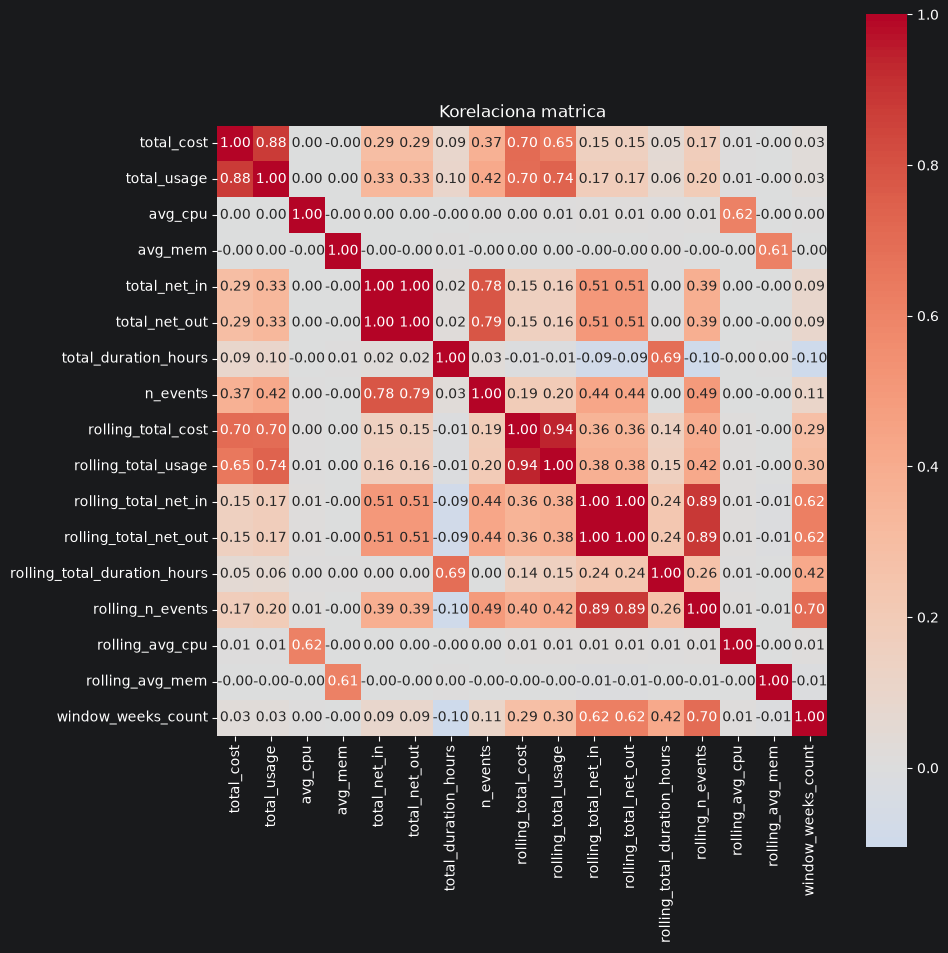

In [663]:

plot_correlation_heatmap(weekly_rolled,num_cols)

### Na osnovu matrice korelacije, može se zaključiti da postoji visoka korelisanost izmedju promenljiva:
Total Usage -> Total Cost <br>
Rolling Total Cost -> Rolling Total Usage <br>
Rolling Total Net In -> Rolling Total Net Out <br>
Rolling N Events -> Rolling Total Net Out/In <br>
Total Net In -> Total Net Out <br>
N Events -> Total Net In/Out <br>
Potrebno je izbaciti ove promenljive iz dataset-a

In [664]:
weekly_rolled = weekly_rolled.drop(columns=[
    "total_usage",
    "total_net_out",
    "rolling_total_net_out",
    "rolling_total_usage",
    "n_events",
    "rolling_n_events",
])

### Testiranje simetricnosti raspodela

Kako bismo omogucili skaliranje promenljivi i efikasni backpropagation, potrebno je testirati simetricnost raspodela promenljvi i transformisati promenljive sa asimetricnom raspodelom

In [665]:
num_cols = ['total_cost','avg_cpu','avg_mem','total_net_in','total_duration_hours','rolling_total_cost','rolling_total_net_in','rolling_total_duration_hours','rolling_avg_cpu','rolling_avg_mem','window_weeks_count']

In [666]:
import numpy as np
def plot_num_cols(df,columns,bins=40):
    n = len(columns)
    ncols = 3
    nrows = int(np.ceil(n/ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize= (6 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        data = df[col].dropna()
        label = col
        axes[i].hist(data, bins=bins,color='blue',edgecolor='black', alpha=0.8)
        axes[i].set_title(label)
        axes[i].set_xlabel(label)
        axes[i].set_ylabel("broj opservacija")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

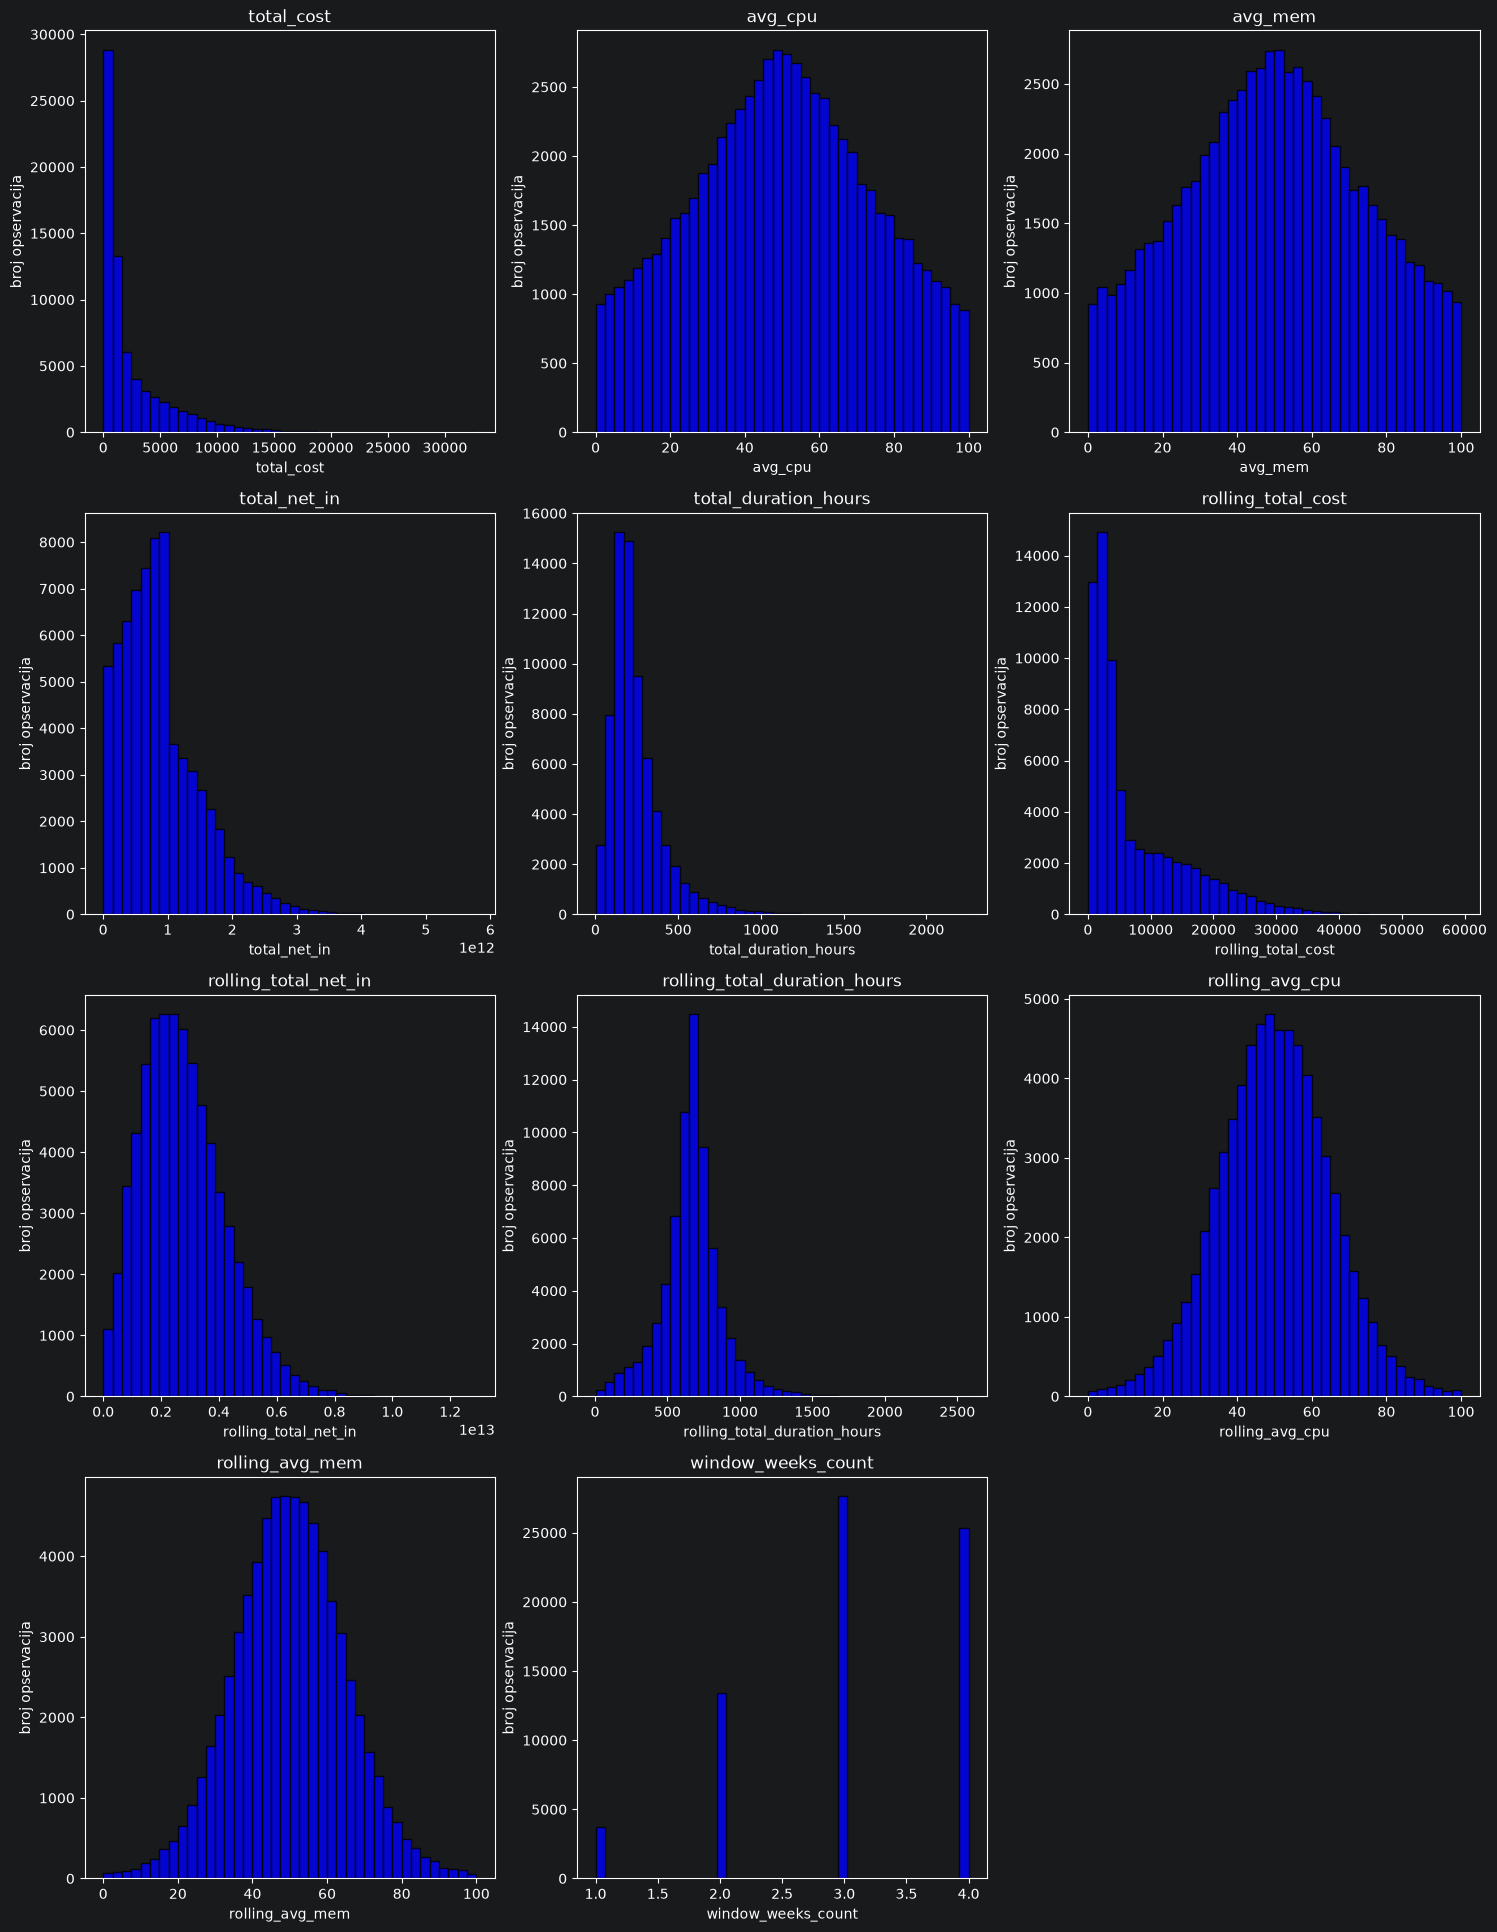

In [667]:
plot_num_cols(weekly_rolled,num_cols)

Takodje cemo uraditi test asimetricnosti kako bismo imali dodatnu potvrdu o asimetricnosti

Na osnovu datih grafikona raspodela može se zaključiti da sumarne metrike imaju raspodelu asimetricnu udesno. Primenicemo logaritamsku tranformaciju kako bismo korigovali ove raspodele

In [668]:
from scipy.stats import skew
for col in num_cols:
    s = skew(weekly_rolled[col].dropna())
    print(f"{col}: skew = {s:.3f}")

total_cost: skew = 2.237
avg_cpu: skew = -0.007
avg_mem: skew = 0.004
total_net_in: skew = 1.219
total_duration_hours: skew = 2.349
rolling_total_cost: skew = 1.576
rolling_total_net_in: skew = 0.703
rolling_total_duration_hours: skew = 0.526
rolling_avg_cpu: skew = -0.011
rolling_avg_mem: skew = 0.021
window_weeks_count: skew = -0.605


In [669]:
weekly_rolled['total_cost'] = np.log1p(weekly_rolled['total_cost'])
weekly_rolled['total_duration_hours'] = np.log1p(weekly_rolled['total_duration_hours'])
weekly_rolled['rolling_total_cost'] = np.log1p(weekly_rolled['rolling_total_cost'])

### Graficki prikaz raspodela transformisanih kolona

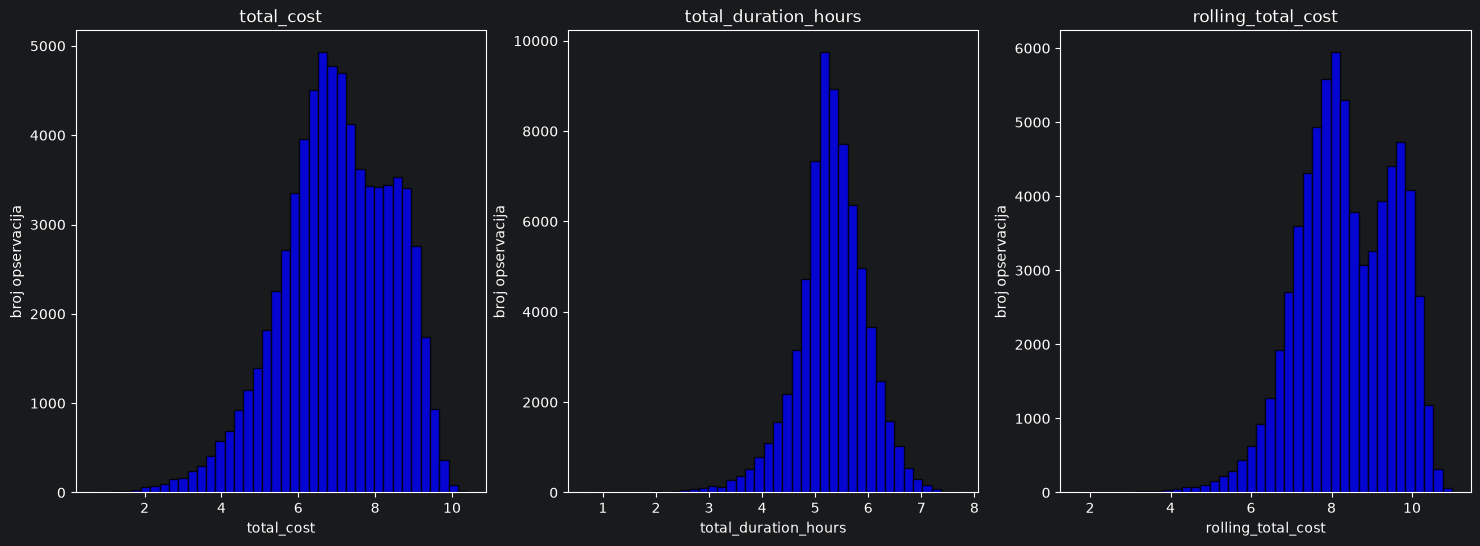

In [670]:
plot_num_cols(weekly_rolled,['total_cost','total_duration_hours','rolling_total_cost'])

Sada sumarne skale teze simetricnim raspodelama

In [671]:
for col in ['total_cost','total_duration_hours','rolling_total_cost']:
    s = skew(weekly_rolled[col].dropna())
    print(f"{col}: skew = {s:.3f}")

total_cost: skew = -0.416
total_duration_hours: skew = -0.603
rolling_total_cost: skew = -0.370


Poslednje sto moramo da uradimo je konvertujemo numericke promenljive service i region u numericke, to cemo postici one-hot encoding-om

In [672]:
def one_hot_encode_col(dataframe, column):
    ohe = pd.get_dummies(dataframe[column], dtype=int)
    df_res = pd.concat([dataframe.drop(columns=column),ohe], axis=1)
    return df_res

In [673]:
weekly_rolled = one_hot_encode_col(weekly_rolled,'service')
weekly_rolled = one_hot_encode_col(weekly_rolled,'region')

In [674]:
weekly_rolled

,total_cost,avg_cpu,avg_mem,total_net_in,total_duration_hours,rolling_total_cost,rolling_total_net_in,rolling_total_duration_hours,rolling_avg_cpu,rolling_avg_mem,...,Cloud Tasks,Compute Engine,Dialogflow,Secret Manager,asia-east1,asia-south1,europe-west1,us-central1,us-east1,us-west1
0,7.929495,86.0900,52.640000,9.477330e+11,6.152733,7.929495,9.477330e+11,469.0,86.09000,52.640000,...,0,0,0,0,0,0,0,0,0,1
1,7.138474,10.4900,16.020000,2.584730e+11,6.042633,8.303141,1.206206e+12,889.0,48.29000,34.330000,...,0,0,0,0,0,0,0,0,0,1
2,7.700486,82.4800,61.010000,5.047120e+11,5.384495,8.151312,7.631850e+11,637.0,46.48500,38.515000,...,0,0,0,0,0,0,0,0,0,1
3,7.066003,67.8300,12.430000,6.496920e+11,4.595120,8.125595,1.154404e+12,315.0,75.15500,36.720000,...,0,0,0,0,0,0,0,0,0,1
4,7.742140,31.7975,49.920000,2.124584e+12,5.476464,8.645107,3.278988e+12,553.0,60.70250,41.120000,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70169,6.267573,85.7400,38.670000,4.021225e+09,5.087596,8.409183,2.334542e+12,678.0,43.10125,41.880000,...,0,0,0,0,0,0,0,0,1,0
70170,4.151530,48.6000,87.120000,3.252350e+11,5.036953,7.900952,1.365256e+12,586.0,54.91375,53.752500,...,0,0,0,0,0,0,0,0,1,0
70171,6.990482,65.6800,11.373333,1.835801e+12,5.361292,7.929229,2.823754e+12,663.0,58.70125,52.672083,...,0,0,0,0,0,0,0,0,1,0
70172,6.440182,78.0300,76.120000,9.159510e+11,4.770685,7.740879,3.081008e+12,643.0,69.51250,53.320833,...,0,0,0,0,0,0,0,0,1,0


In [676]:
weekly_rolled.info()

<class 'pandas.DataFrame'>
RangeIndex: 70174 entries, 0 to 70173
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   total_cost                    70174 non-null  float64
 1   avg_cpu                       70174 non-null  float64
 2   avg_mem                       70174 non-null  float64
 3   total_net_in                  70174 non-null  float64
 4   total_duration_hours          70174 non-null  float64
 5   rolling_total_cost            70174 non-null  float64
 6   rolling_total_net_in          70174 non-null  float64
 7   rolling_total_duration_hours  70174 non-null  float64
 8   rolling_avg_cpu               70174 non-null  float64
 9   rolling_avg_mem               70174 non-null  float64
 10  window_weeks_count            70174 non-null  int64  
 11  App Engine                    70174 non-null  int64  
 12  Artifact Registry             70174 non-null  int64  
 13  BigQuery    

## Skaliranje podataka i treniranje modela

In [675]:
#TODO: Uraditi StandardScaler nad Svim numerickim podacima osim one hot encoded kolona
#TODO: Pri predikciji iskoristiti eksponencijalnu transformaciju nad promenljivama koje su logaritamski transformisane